#  week 8
# PCA, K-means, elbow method

# ELBOW method finding the k-means cluster number

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 
from sklearn.cluster import KMeans
from sklearn import datasets
iris = datasets.load_iris()

#we are usingh
df=pd.DataFrame(iris['data'])

print(df.head())

     0    1    2    3
0  5.1  3.5  1.4  0.2
1  4.9  3.0  1.4  0.2
2  4.7  3.2  1.3  0.2
3  4.6  3.1  1.5  0.2
4  5.0  3.6  1.4  0.2


In [12]:
# Running K-Means with a range of k
# We can easily run K-Means for a range of clusters using a for loop and collecting the distortions into a list.

distortions = []
K = range(1,10)
for k in K:
    kmeanModel = KMeans(n_clusters=k)
    kmeanModel.fit(df)
    distortions.append(kmeanModel.inertia_)

C:\Users\micha\anaconda3\envs\02502_IA_1\lib\site-packages\sklearn\cluster\_kmeans.py:1036: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


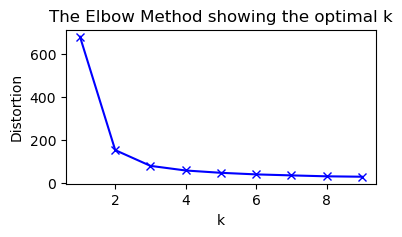

In [14]:
plt.figure(figsize=(4,2))
plt.plot(K, distortions, 'bx-')
plt.xlabel('k')
plt.ylabel('Distortion')
plt.title('The Elbow Method showing the optimal k')
plt.show()

We can observe that the “elbow” is the number 3 which is optimal for this case. Now we can run a K-Means using as n_clusters the number 3.

## PCA to check for varaince explained.

In [28]:
import numpy as np
import sklearn as sk
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# try to import pandas
# if it doesnt exist pip install it 
# if this fails delete it and manuall install pandas(pip install pandas)
try:
    import pandas as pd
except ImportError as e:
    !pip install pandas
    import pandas as pd

%matplotlib inline

# plot data and fit (2d only)
def plot_fit(X, y, clf):
    """
    X = samples
    y = Ground truth
    clf = trained model
    """
    h = .02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    fig = plt.figure(1, figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

    # Plot also the training points
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors= "black")
    plt.xlabel('Sepal length')
    plt.ylabel('Sepal width')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xticks(())
    plt.yticks(())

In [29]:
# import some data to play with
iris = sk.datasets.load_iris()
iris_df = df#pd.DataFrame(iris.data, columns = iris.feature_names)
display(iris_df)
X = StandardScaler().fit_transform(iris_df)
target = iris.target
print ("Number of data points ::", X.shape[0])
print("Number of features ::", X.shape[1])

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


Number of data points :: 150
Number of features :: 4


In [34]:
### HERE goes the elbow number
pca = PCA(n_components=3)
principalComponents = pca.fit_transform(X)
principalDf = pd.DataFrame(data = principalComponents
             , columns = ['principal component 1', 'principal component 2','pc3'])
display(principalDf)

#plt.figure()
#plt.scatter(X[:,0], X[:,1])
#plt.scatter(principalComponents[:,0], principalComponents[:,1])
#lt.legend(['The first 2 attributes of X','Principle Components'])

,principal component 1,principal component 2,pc3
0,-2.264703,0.480027,-0.127706
1,-2.080961,-0.674134,-0.234609
2,-2.364229,-0.341908,0.044201
3,-2.299384,-0.597395,0.091290
4,-2.389842,0.646835,0.015738
...,...,...,...
145,1.870503,0.386966,0.256274
146,1.564580,-0.896687,-0.026371
147,1.521170,0.269069,0.180178
148,1.372788,1.011254,0.933395


## Explained Variance
The explained variance tells you how much information (variance) can be attributed to each of the principal components. 

By using the attribute explained_variance_ratio_, you can see that the first principal component contains 72.77% of the variance and the second principal component contains 23.03% of the variance.

In [35]:
print(pca.explained_variance_ratio_[0])
sum=0
for i in range(len(pca.explained_variance_ratio_)):
    sum =sum+pca.explained_variance_ratio_[i]
    print(f"sum: {sum}")


0.7296244541329985
sum: 0.7296244541329985
sum: 0.9581320720000164
sum: 0.9948212908928451


In [36]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Load the iris dataset
iris = load_iris()

# Apply PCA to reduce the dimensionality of the dataset
pca = PCA(n_components=2)
iris_pca = pca.fit_transform(iris.data)

# Perform K-means clustering on the transformed data
kmeans = KMeans(n_clusters=3)
kmeans.fit(iris_pca)

# Calculate the inertia
inertia = kmeans.inertia_

print(f"Inertia: {inertia}")


Inertia: 63.8199420220012


(100, 10)


C:\Users\micha\anaconda3\envs\02502_IA_1\lib\site-packages\sklearn\cluster\_kmeans.py:1036: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


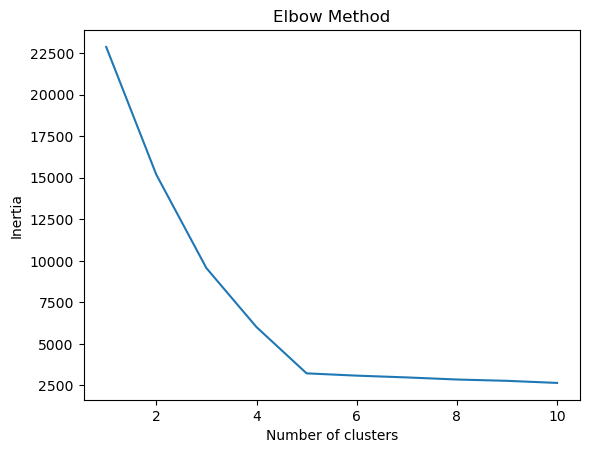

In [38]:
# QUIZZ 3 elbow method 
# CHAT GPT
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load the dataset into X
X = np.loadtxt('clusters.txt')
print(X.shape)
# Initialize empty list to store the inertia values
inertia_values = []

# Loop over different numbers of clusters to calculate the inertia
for n in range(1, 11):
    km = KMeans(n_clusters=n)
    km.fit(X)
    inertia_values.append(km.inertia_)

# Plot the elbow curve
plt.plot(range(1, 11), inertia_values)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()


a = 0.55
b = 19.86


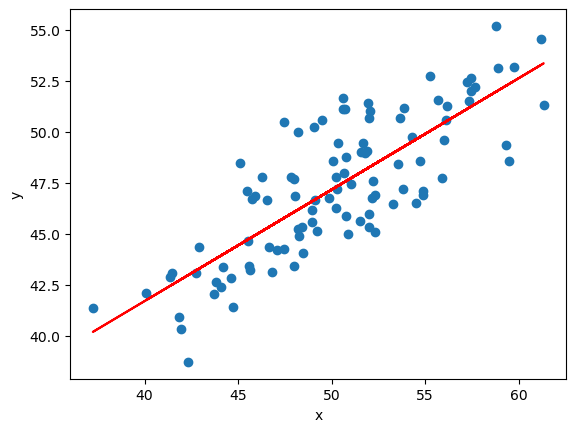

In [41]:
# QUIZZ3 linear regression
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Load the data from 'link1' and 'link2'
x = np.loadtxt('lr_x.txt')
y = np.loadtxt('lr_y.txt')

# Reshape the data to 2D arrays
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

# Create a linear regression object and fit the data
reg = LinearRegression().fit(x, y)

# Get the parameters of the linear regression model
a = reg.coef_[0][0]
b = reg.intercept_[0]

# Print the parameters
print(f"a = {a:.2f}")
print(f"b = {b:.2f}")

# Plot the data and the linear regression line
plt.scatter(x, y)
plt.plot(x, reg.predict(x), color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.show()
